In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
os.listdir('/content/drive/MyDrive/AML_Project')

['elliptic_txs_edgelist.csv',
 'elliptic_txs_classes.csv',
 'elliptic_txs_features.csv']

In [ ]:
import pandas as pd

features = pd.read_csv(
    '/content/drive/MyDrive/AML_Project/elliptic_txs_features.csv',
    header=None
)

edges = pd.read_csv(
    '/content/drive/MyDrive/AML_Project/elliptic_txs_edgelist.csv'
)

classes = pd.read_csv(
    '/content/drive/MyDrive/AML_Project/elliptic_txs_classes.csv'
)

In [ ]:
features.head()

,0,1,2,3,4,5,6,7,8,9,...,157,158,159,160,161,162,163,164,165,166
0,230425980,1,-0.171469,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162097,...,-0.562153,-0.600999,1.461330,1.461369,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792
1,5530458,1,-0.171484,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162112,...,0.947382,0.673103,-0.979074,-0.978556,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792
2,232022460,1,-0.172107,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162749,...,0.670883,0.439728,-0.979074,-0.978556,-0.098889,-0.106715,-0.131155,-0.183671,-0.120613,-0.119792
3,232438397,1,0.163054,1.963790,-0.646376,12.409294,-0.063725,9.782742,12.414558,-0.163645,...,-0.577099,-0.613614,0.241128,0.241406,1.072793,0.085530,-0.131155,0.677799,-0.120613,-0.119792
4,230460314,1,1.011523,-0.081127,-1.201369,1.153668,0.333276,1.312656,-0.061584,-0.163523,...,-0.511871,-0.400422,0.517257,0.579382,0.018279,0.277775,0.326394,1.293750,0.178136,0.179117


In [ ]:
!pip install pandas numpy matplotlib seaborn networkx

In [ ]:
features.head()
features.shape

(203769, 167)

In [ ]:
edges.head()

,txId1,txId2
0,230425980,5530458
1,232022460,232438397
2,230460314,230459870
3,230333930,230595899
4,232013274,232029206


In [ ]:
classes.head()
classes['class'].value_counts()

,count
class,
unknown,157205
2,42019
1,4545


In [ ]:
# Rename columns for clarity
features.rename(columns={0: "txId", 1: "time_step"}, inplace=True)

# Merge features + classes
df = features.merge(classes, on="txId", how="left")

df.head()

,txId,time_step,2,3,4,5,6,7,8,9,...,158,159,160,161,162,163,164,165,166,class
0,230425980,1,-0.171469,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162097,...,-0.600999,1.461330,1.461369,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792,unknown
1,5530458,1,-0.171484,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162112,...,0.673103,-0.979074,-0.978556,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792,unknown
2,232022460,1,-0.172107,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162749,...,0.439728,-0.979074,-0.978556,-0.098889,-0.106715,-0.131155,-0.183671,-0.120613,-0.119792,unknown
3,232438397,1,0.163054,1.963790,-0.646376,12.409294,-0.063725,9.782742,12.414558,-0.163645,...,-0.613614,0.241128,0.241406,1.072793,0.085530,-0.131155,0.677799,-0.120613,-0.119792,2
4,230460314,1,1.011523,-0.081127,-1.201369,1.153668,0.333276,1.312656,-0.061584,-0.163523,...,-0.400422,0.517257,0.579382,0.018279,0.277775,0.326394,1.293750,0.178136,0.179117,unknown


In [ ]:
# Convert labels
df['class'] = df['class'].replace({
    'unknown': -1,
    '1': 1,
    '2': 0
})

/tmp/ipykernel_5340/3866272614.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['class'] = df['class'].replace({


In [ ]:
df['class'].value_counts()

,count
class,
-1,157205
0,42019
1,4545


In [ ]:
features.head()

,txId,time_step,2,3,4,5,6,7,8,9,...,157,158,159,160,161,162,163,164,165,166
0,230425980,1,-0.171469,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162097,...,-0.562153,-0.600999,1.461330,1.461369,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792
1,5530458,1,-0.171484,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162112,...,0.947382,0.673103,-0.979074,-0.978556,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792
2,232022460,1,-0.172107,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162749,...,0.670883,0.439728,-0.979074,-0.978556,-0.098889,-0.106715,-0.131155,-0.183671,-0.120613,-0.119792
3,232438397,1,0.163054,1.963790,-0.646376,12.409294,-0.063725,9.782742,12.414558,-0.163645,...,-0.577099,-0.613614,0.241128,0.241406,1.072793,0.085530,-0.131155,0.677799,-0.120613,-0.119792
4,230460314,1,1.011523,-0.081127,-1.201369,1.153668,0.333276,1.312656,-0.061584,-0.163523,...,-0.511871,-0.400422,0.517257,0.579382,0.018279,0.277775,0.326394,1.293750,0.178136,0.179117


In [ ]:
features.shape

(203769, 167)

In [ ]:
features.columns

Index([     'txId', 'time_step',           2,           3,           4,
                 5,           6,           7,           8,           9,
       ...
               157,         158,         159,         160,         161,
               162,         163,         164,         165,         166],
      dtype='object', length=167)

In [ ]:
features.rename(columns={
    0: "txId",
    1: "time_step"
}, inplace=True)

In [ ]:
features.head()

,txId,time_step,2,3,4,5,6,7,8,9,...,157,158,159,160,161,162,163,164,165,166
0,230425980,1,-0.171469,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162097,...,-0.562153,-0.600999,1.461330,1.461369,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792
1,5530458,1,-0.171484,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162112,...,0.947382,0.673103,-0.979074,-0.978556,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792
2,232022460,1,-0.172107,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162749,...,0.670883,0.439728,-0.979074,-0.978556,-0.098889,-0.106715,-0.131155,-0.183671,-0.120613,-0.119792
3,232438397,1,0.163054,1.963790,-0.646376,12.409294,-0.063725,9.782742,12.414558,-0.163645,...,-0.577099,-0.613614,0.241128,0.241406,1.072793,0.085530,-0.131155,0.677799,-0.120613,-0.119792
4,230460314,1,1.011523,-0.081127,-1.201369,1.153668,0.333276,1.312656,-0.061584,-0.163523,...,-0.511871,-0.400422,0.517257,0.579382,0.018279,0.277775,0.326394,1.293750,0.178136,0.179117


In [ ]:
df = features.merge(classes, on="txId", how="left")

In [ ]:
df.head()

,txId,time_step,2,3,4,5,6,7,8,9,...,158,159,160,161,162,163,164,165,166,class
0,230425980,1,-0.171469,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162097,...,-0.600999,1.461330,1.461369,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792,unknown
1,5530458,1,-0.171484,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162112,...,0.673103,-0.979074,-0.978556,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792,unknown
2,232022460,1,-0.172107,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162749,...,0.439728,-0.979074,-0.978556,-0.098889,-0.106715,-0.131155,-0.183671,-0.120613,-0.119792,unknown
3,232438397,1,0.163054,1.963790,-0.646376,12.409294,-0.063725,9.782742,12.414558,-0.163645,...,-0.613614,0.241128,0.241406,1.072793,0.085530,-0.131155,0.677799,-0.120613,-0.119792,2
4,230460314,1,1.011523,-0.081127,-1.201369,1.153668,0.333276,1.312656,-0.061584,-0.163523,...,-0.400422,0.517257,0.579382,0.018279,0.277775,0.326394,1.293750,0.178136,0.179117,unknown


In [ ]:
df.shape

(203769, 168)

In [ ]:
df.isnull().sum()

,0
txId,0
time_step,0
2,0
3,0
4,0
...,...
163,0
164,0
165,0
166,0


In [ ]:
df['class'].unique()

array(['unknown', '2', '1'], dtype=object)

In [ ]:
df['class'] = df['class'].replace({
    'unknown': -1,
    '1': 1,
    '2': 0
})

/tmp/ipykernel_5340/28201325.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['class'] = df['class'].replace({


In [ ]:
df['class'].value_counts()

,count
class,
-1,157205
0,42019
1,4545


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 203769 entries, 0 to 203768
Columns: 168 entries, txId to class
dtypes: float64(165), int64(3)
memory usage: 261.2 MB


In [ ]:
df.describe()

,txId,time_step,2,3,4,5,6,7,8,9,...,158,159,160,161,162,163,164,165,166,class
count,2.037690e+05,203769.000000,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,...,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,2.037690e+05,203769.000000
mean,1.711310e+08,23.843961,2.454849e-17,-7.531922e-18,2.231681e-17,6.241732e-17,7.653968e-17,5.858162e-17,3.068561e-17,3.570689e-17,...,1.673761e-16,-7.225066e-17,7.476130e-17,-4.658634e-17,2.231681e-18,5.244450e-17,1.562177e-17,4.072817e-17,5.913954e-17,-0.749182
std,1.104655e+08,15.172170,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,...,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,0.482202
min,1.076000e+03,1.000000,-1.729826e-01,-2.105526e-01,-1.756361e+00,-1.219696e-01,-6.372457e-02,-1.130020e-01,-6.158379e-02,-1.636459e-01,...,-6.262286e-01,-9.790738e-01,-9.785560e-01,-2.160569e-01,-1.259391e-01,-1.311553e-01,-2.698175e-01,-1.760926e+00,-1.760984e+00,-1.000000
25%,8.433452e+07,9.000000,-1.725317e-01,-1.803266e-01,-1.201369e+00,-1.219696e-01,-4.387455e-02,-1.130020e-01,-6.158379e-02,-1.635168e-01,...,-5.946915e-01,-9.790738e-01,-9.785560e-01,-9.888874e-02,-8.749016e-02,-1.311553e-01,-1.405971e-01,-1.206134e-01,-1.197925e-01,-1.000000
50%,1.624375e+08,23.000000,-1.692045e-01,-1.328975e-01,4.636092e-01,-1.219696e-01,-4.387455e-02,-1.130020e-01,-6.158379e-02,-1.620440e-01,...,-4.559278e-01,2.411283e-01,2.414064e-01,1.827940e-02,-8.749016e-02,-1.311553e-01,-9.752359e-02,-1.206134e-01,-1.197925e-01,-1.000000
75%,2.454798e+08,38.000000,-1.318553e-01,-5.524241e-02,1.018602e+00,-1.219696e-01,-4.387455e-02,-1.130020e-01,-6.158379e-02,-1.355932e-01,...,1.212026e-01,1.305594e+00,1.398764e+00,1.827940e-02,-8.749016e-02,-8.467423e-02,-9.752359e-02,1.520067e-01,1.199710e-01,-1.000000
max,4.032446e+08,49.000000,7.168197e+01,7.359505e+01,2.683580e+00,4.902760e+01,2.600907e+02,5.456518e+01,1.134409e+02,7.335457e+01,...,7.914041e+00,1.461330e+00,1.461369e+00,1.170692e+02,2.518490e+02,2.387835e+02,1.057340e+02,1.519700e+00,1.521399e+00,1.000000


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

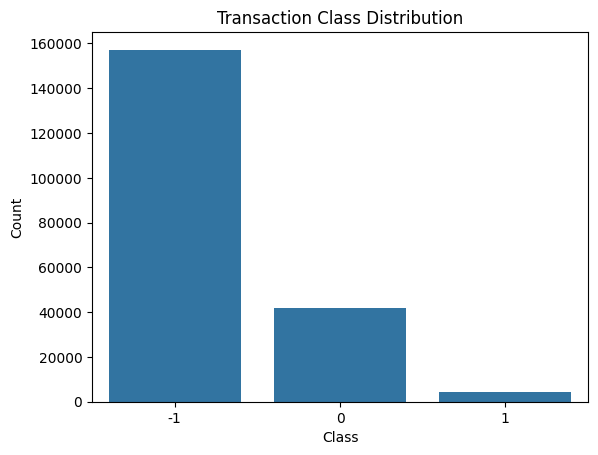

In [ ]:
sns.countplot(x='class', data=df)

plt.title("Transaction Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")

plt.show()

In [ ]:
df['class'].value_counts(normalize=True) * 100

,proportion
class,
-1,77.148634
0,20.620899
1,2.230467


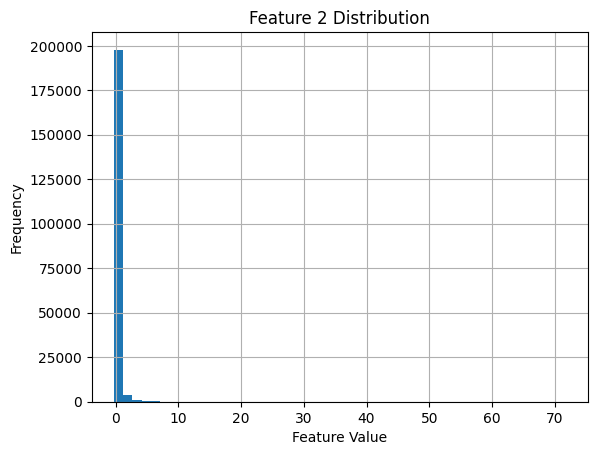

In [ ]:
df[2].hist(bins=50)

plt.title("Feature 2 Distribution")
plt.xlabel("Feature Value")
plt.ylabel("Frequency")

plt.show()

In [ ]:
licit_df = df[df['class'] == 0]
illicit_df = df[df['class'] == 1]
unknown_df = df[df['class'] == -1]

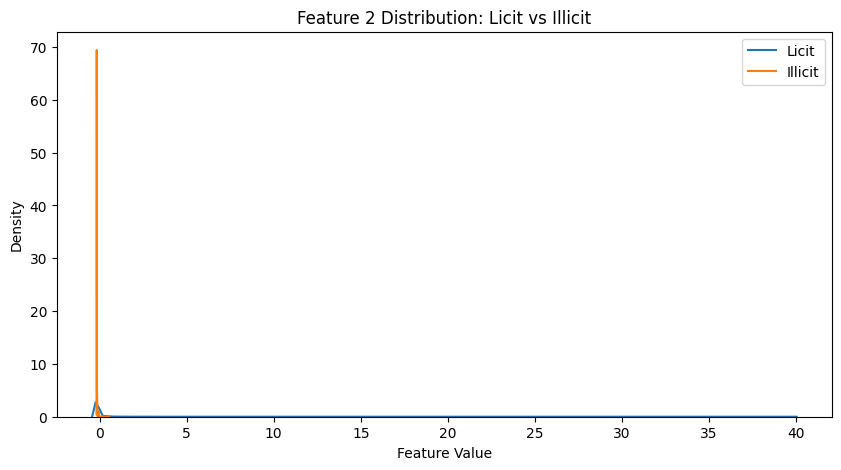

In [ ]:
plt.figure(figsize=(10,5))

sns.kdeplot(licit_df[2], label='Licit')
sns.kdeplot(illicit_df[2], label='Illicit')

plt.title("Feature 2 Distribution: Licit vs Illicit")
plt.xlabel("Feature Value")
plt.ylabel("Density")

plt.legend()

plt.show()

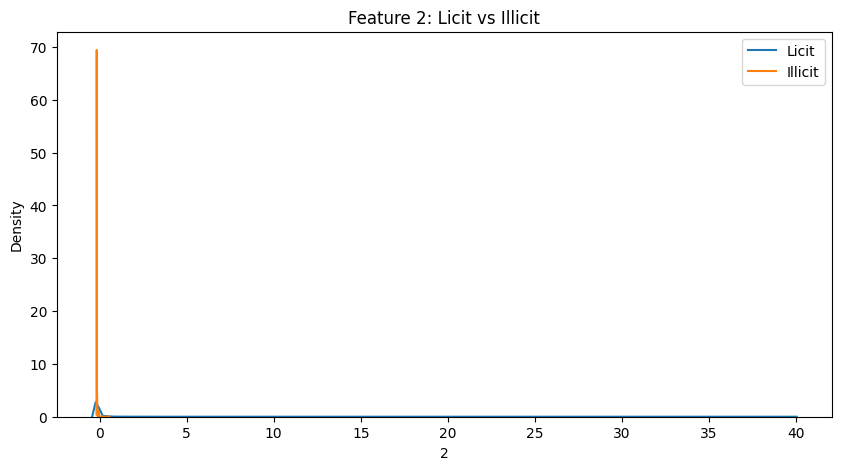

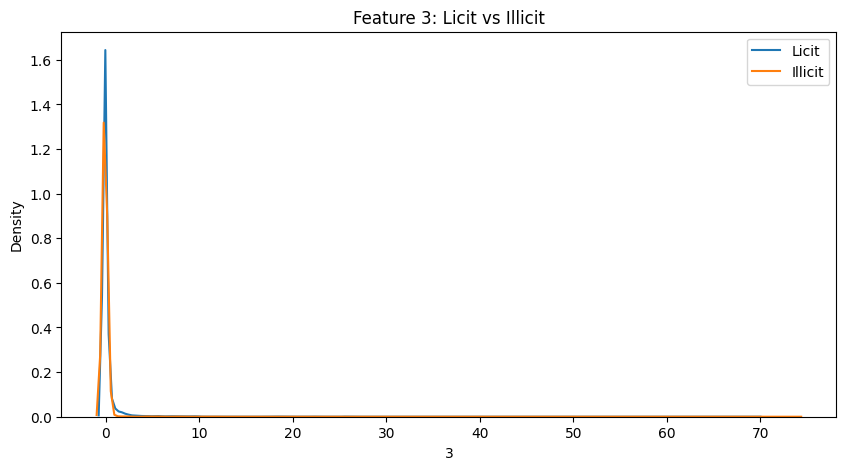

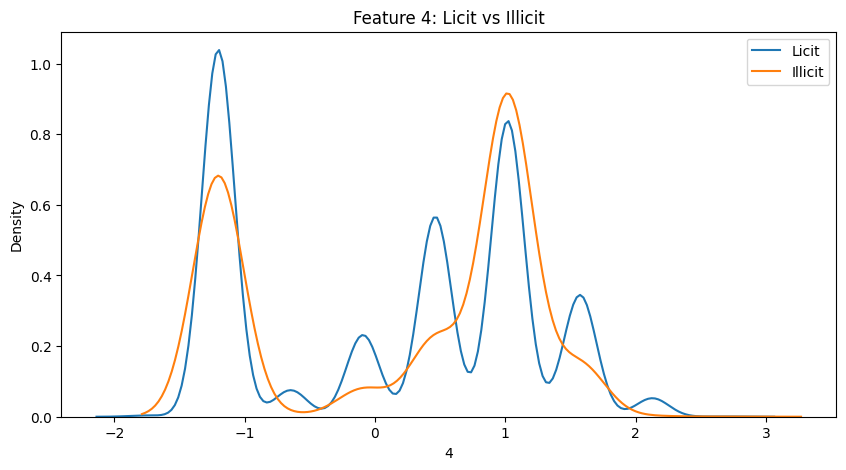

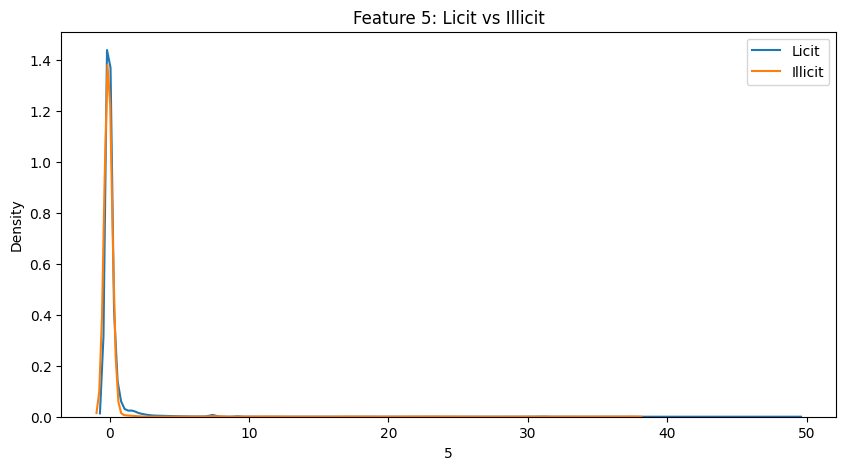

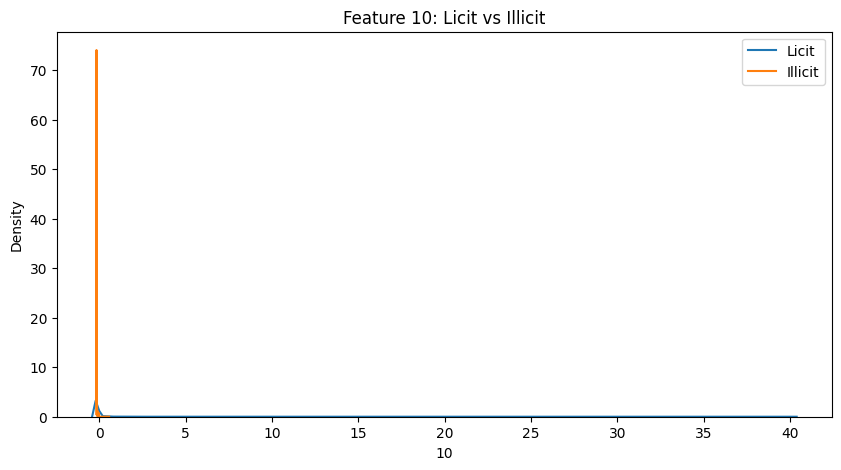

In [ ]:
features_to_check = [2, 3, 4, 5, 10]

for feature in features_to_check:

    plt.figure(figsize=(10,5))

    sns.kdeplot(licit_df[feature], label='Licit')
    sns.kdeplot(illicit_df[feature], label='Illicit')

    plt.title(f"Feature {feature}: Licit vs Illicit")
    plt.legend()

    plt.show()

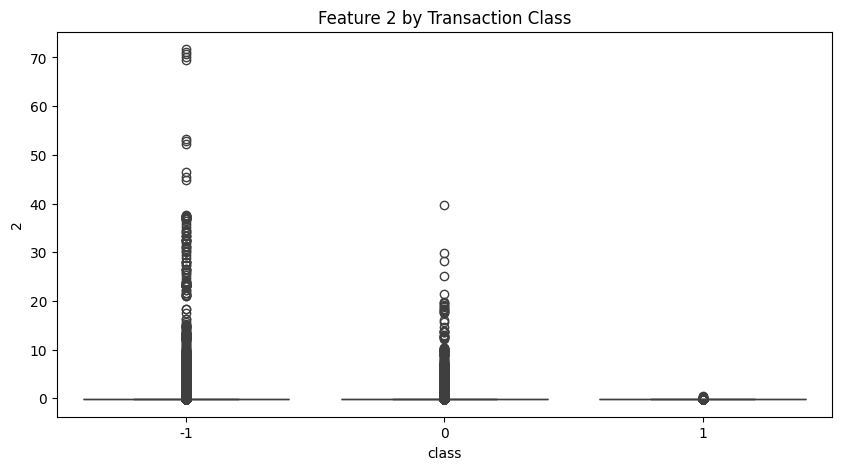

In [ ]:
plt.figure(figsize=(10,5))

sns.boxplot(x='class', y=2, data=df)

plt.title("Feature 2 by Transaction Class")

plt.show()

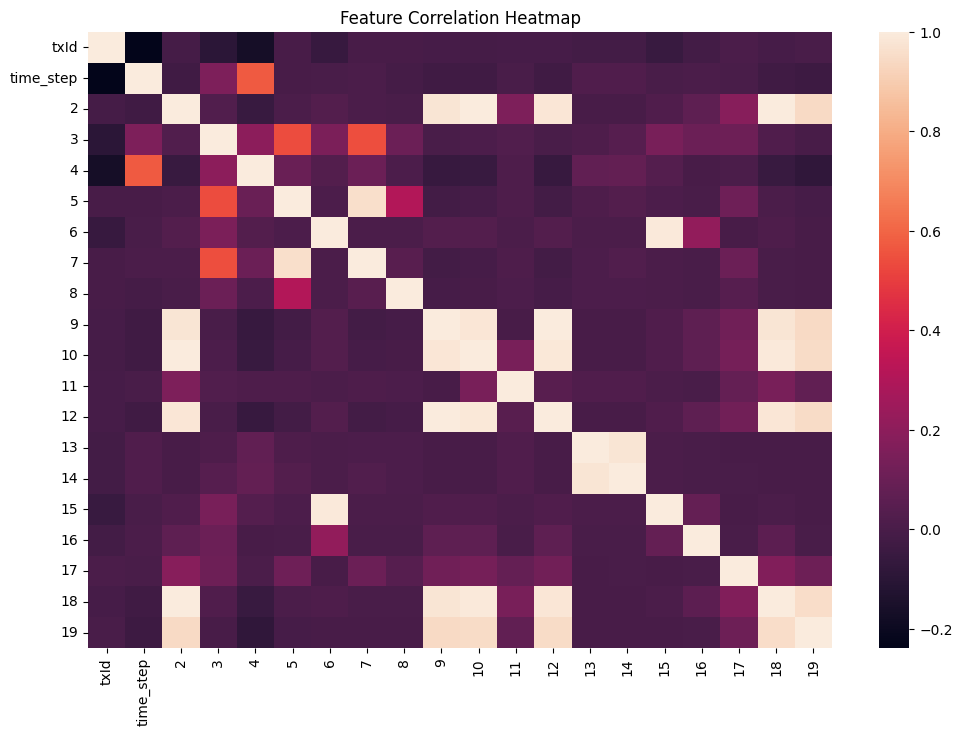

In [ ]:
plt.figure(figsize=(12,8))

correlation = df.iloc[:, 0:20].corr()

sns.heatmap(correlation)

plt.title("Feature Correlation Heatmap")

plt.show()

In [ ]:
import networkx as nx

In [ ]:
G = nx.from_pandas_edgelist(
    edges,
    source='txId1',
    target='txId2',
    create_using=nx.DiGraph()
)

In [ ]:
print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())

Number of nodes: 203769
Number of edges: 234355


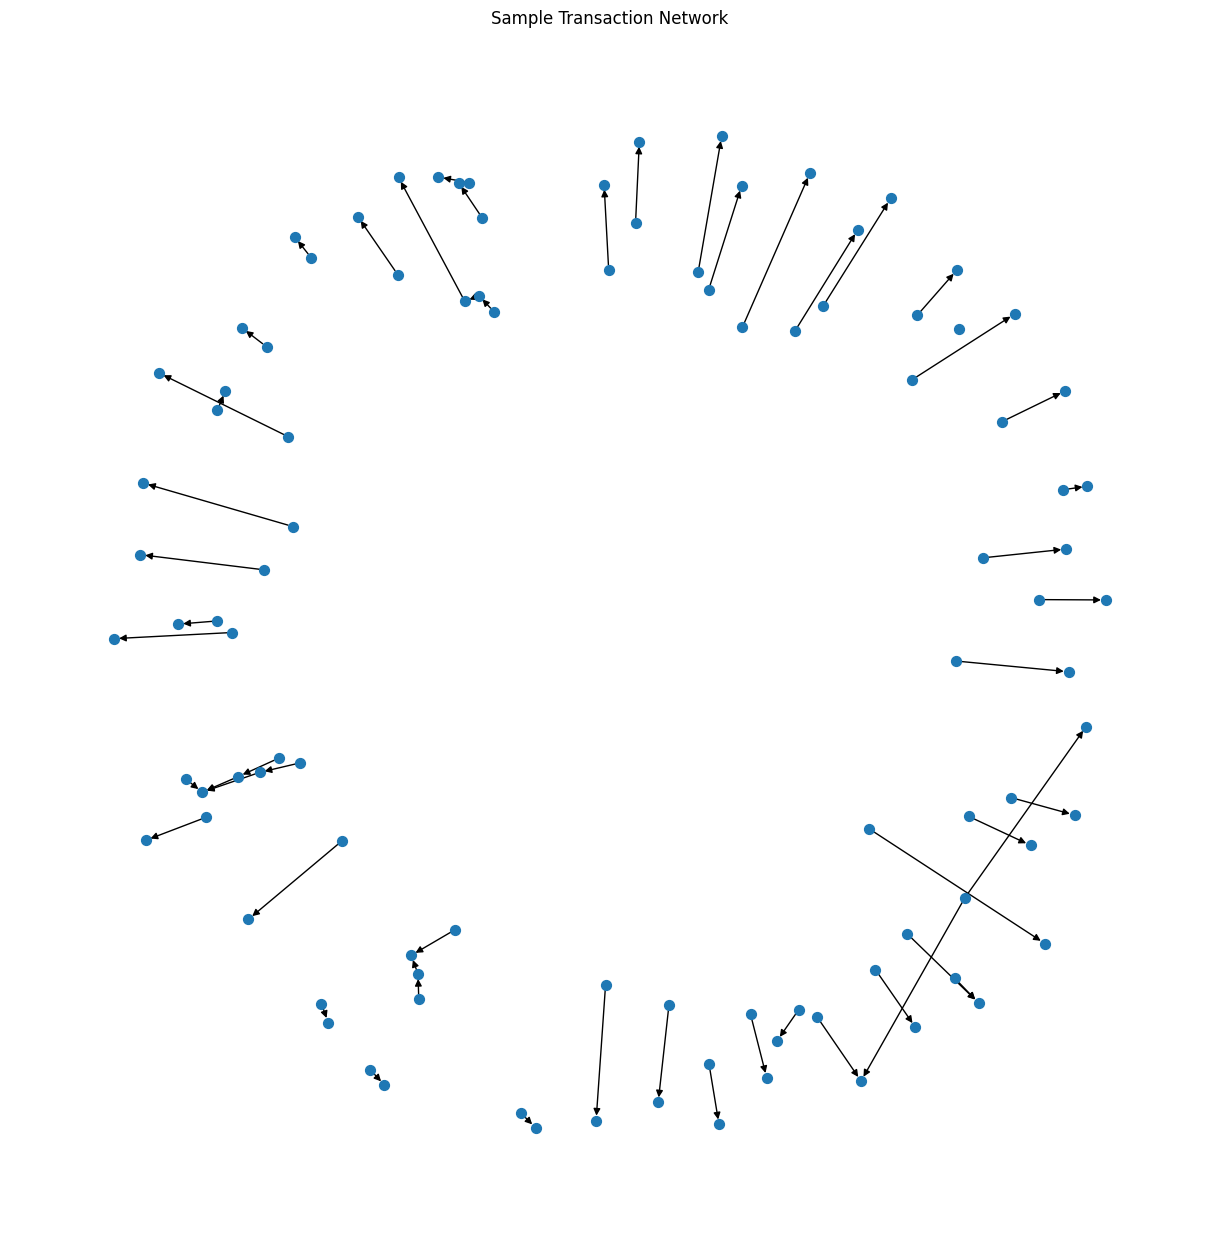

In [ ]:
sample_nodes = list(G.nodes())[:100]

subgraph = G.subgraph(sample_nodes)

plt.figure(figsize=(12,12))

nx.draw(
    subgraph,
    node_size=50,
    with_labels=False
)

plt.title("Sample Transaction Network")

plt.show()

In [ ]:
class_map = df.set_index('txId')['class'].to_dict()

In [ ]:
node_colors = []

for node in subgraph.nodes():

    node_class = class_map.get(node, -1)

    if node_class == 1:
        node_colors.append('red')

    elif node_class == 0:
        node_colors.append('green')

    else:
        node_colors.append('gray')

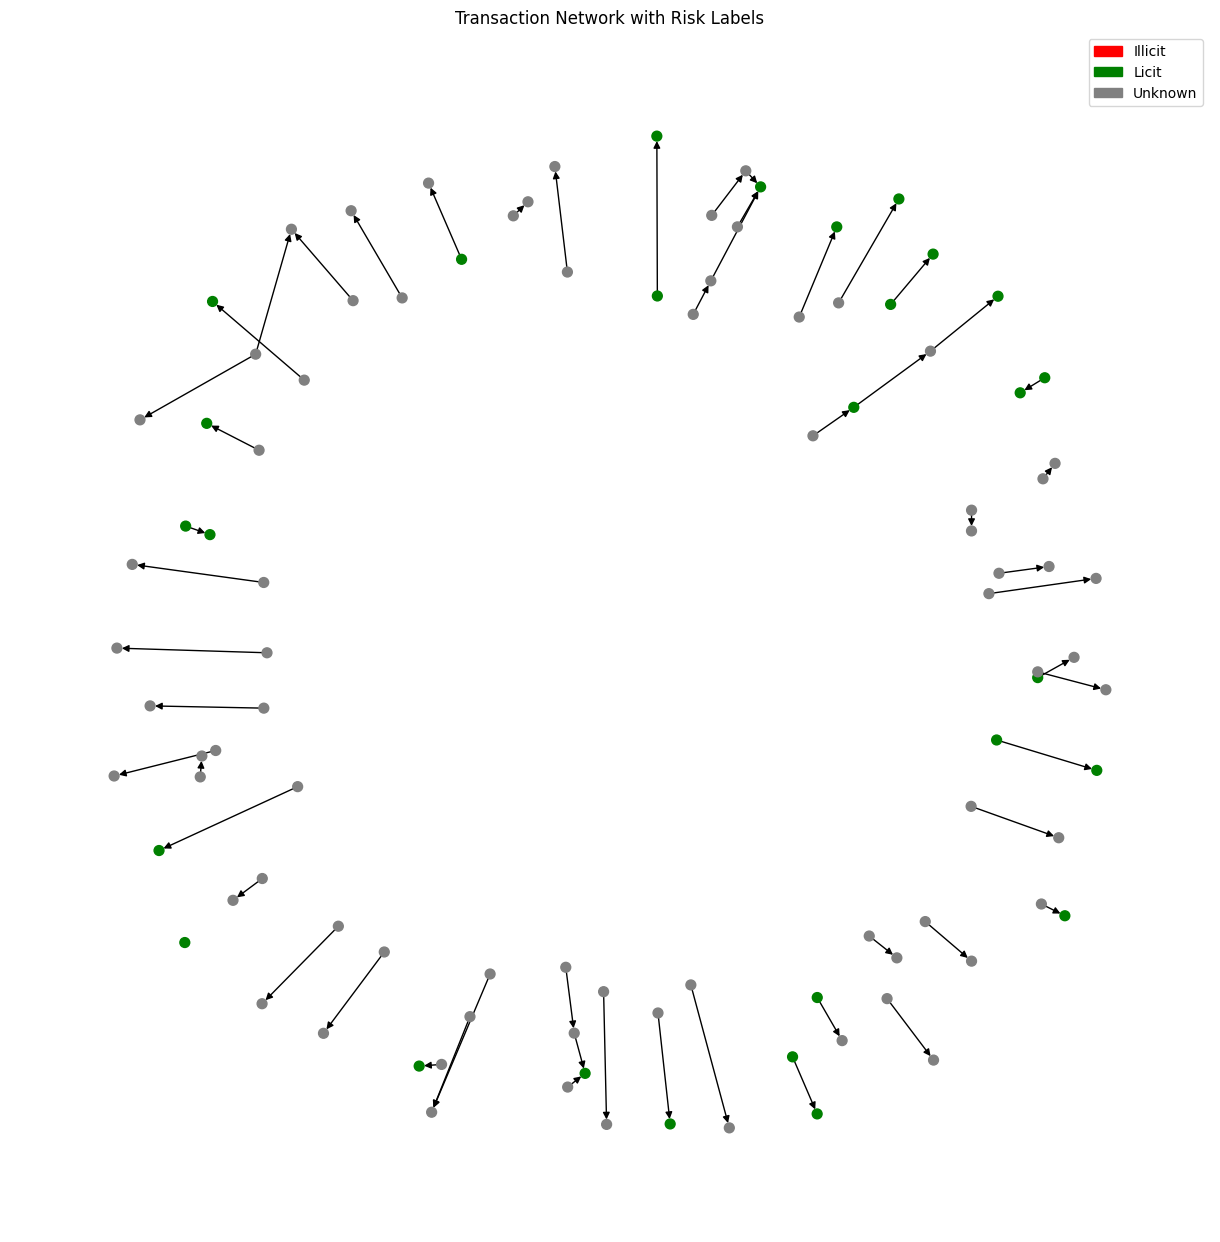

In [ ]:
plt.figure(figsize=(12,12))

nx.draw(
    subgraph,
    node_color=node_colors,
    node_size=50,
    with_labels=False
)

# Create legend
import matplotlib.patches as mpatches

red_patch = mpatches.Patch(color='red', label='Illicit')
green_patch = mpatches.Patch(color='green', label='Licit')
gray_patch = mpatches.Patch(color='gray', label='Unknown')

plt.legend(handles=[red_patch, green_patch, gray_patch])

plt.title("Transaction Network with Risk Labels")

plt.show()

In [ ]:
degree_dict = dict(G.degree())

In [ ]:
df['degree'] = df['txId'].map(degree_dict)

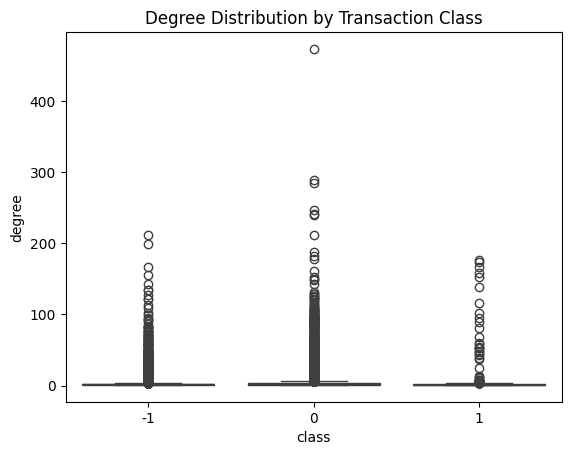

In [ ]:
sns.boxplot(x='class', y='degree', data=df)

plt.title("Degree Distribution by Transaction Class")

plt.show()

In [ ]:
df[['txId', 'class', 'degree']].sort_values(
    by='degree',
    ascending=False
).head(10)

,txId,class,degree
94301,2984918,0,473
130,89273,0,289
51371,43388675,0,284
51437,68705820,0,247
148292,30699343,0,241
35892,96576418,0,239
24761,225859042,-1,212
19138,279187194,0,211
58098,234890810,-1,199
189738,196107869,0,188


In [ ]:
subgraph_classes = []

for node in subgraph.nodes():
    subgraph_classes.append(class_map.get(node, -1))

pd.Series(subgraph_classes).value_counts()

,count
-1,72
0,28


In [ ]:
illicit_tx = df[df['class'] == 1]['txId'].iloc[0]

illicit_tx

np.int64(232629023)

In [ ]:
neighbors = list(G.neighbors(illicit_tx))

neighbors[:10]

[231573972]

In [ ]:
small_nodes = [illicit_tx] + neighbors[:15]

small_subgraph = G.subgraph(small_nodes)

In [ ]:
small_colors = []

for node in small_subgraph.nodes():

    node_class = class_map.get(node, -1)

    if node_class == 1:
        small_colors.append('red')

    elif node_class == 0:
        small_colors.append('green')

    else:
        small_colors.append('gray')

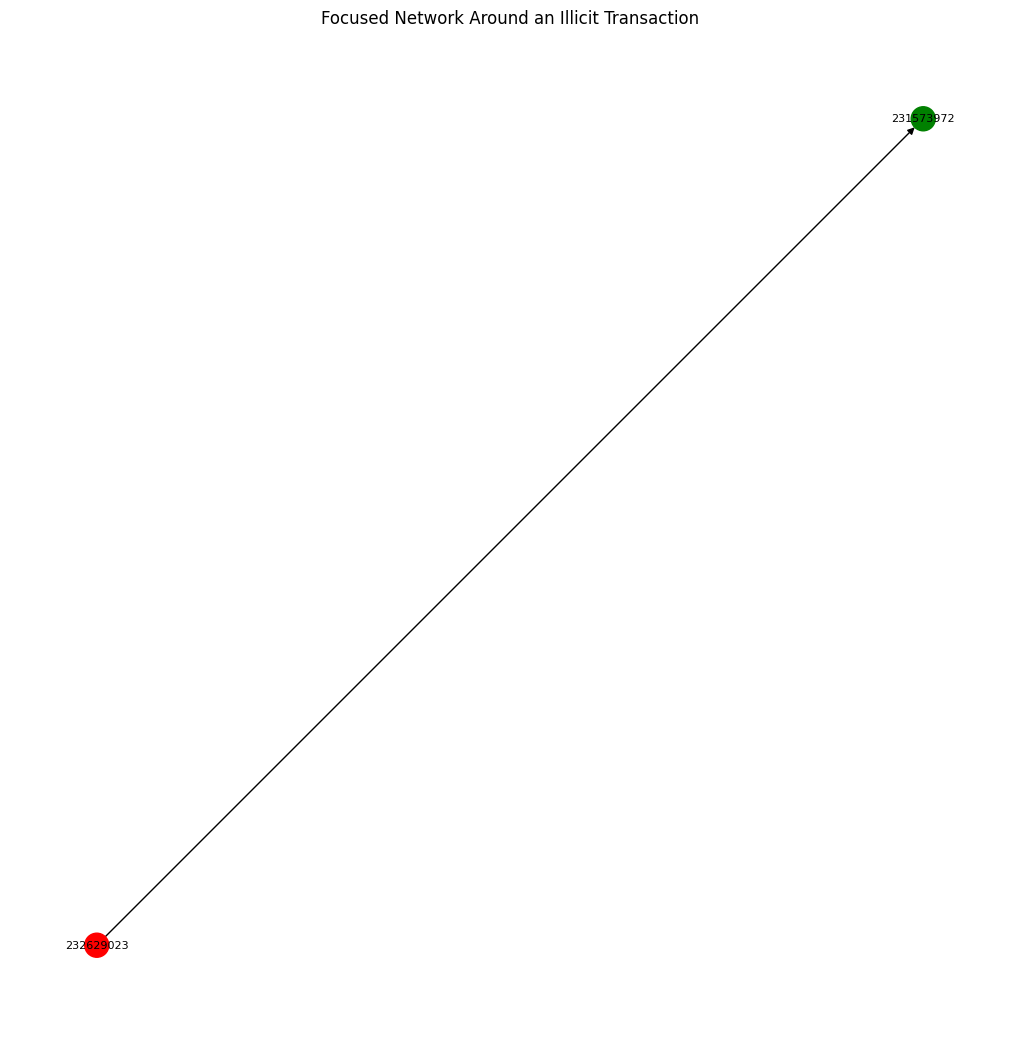

In [ ]:
plt.figure(figsize=(10,10))

nx.draw(
    small_subgraph,
    node_color=small_colors,
    with_labels=True,
    node_size=300,
    font_size=8
)

plt.title("Focused Network Around an Illicit Transaction")

plt.show()

In [ ]:
illicit_neighbor_count = {}

for node in G.nodes():

    neighbors = list(G.neighbors(node))

    illicit_count = 0

    for neighbor in neighbors:

        if class_map.get(neighbor) == 1:
            illicit_count += 1

    illicit_neighbor_count[node] = illicit_count

In [ ]:
df['illicit_neighbors'] = df['txId'].map(illicit_neighbor_count)

In [ ]:
df[['txId', 'class', 'illicit_neighbors']].sort_values(
    by='illicit_neighbors',
    ascending=False
).head(20)

,txId,class,illicit_neighbors
127576,355092392,-1,8
151713,4732368,-1,7
151759,8695835,-1,7
162783,12776876,-1,6
151576,26532670,-1,6
151666,2842440,-1,6
163802,12716727,-1,5
152011,17124347,-1,5
154653,8373032,-1,5
87316,65263113,-1,5


In [ ]:
df[df['class'] == -1][
    ['txId', 'illicit_neighbors']
].sort_values(
    by='illicit_neighbors',
    ascending=False
).head(20)

,txId,illicit_neighbors
127576,355092392,8
151759,8695835,7
151713,4732368,7
151666,2842440,6
162783,12776876,6
151576,26532670,6
154653,8373032,5
152011,17124347,5
87316,65263113,5
163249,12661072,5


In [ ]:
df['risk_score'] = (
    df['illicit_neighbors'] * 50
)

In [ ]:
df[
    ['txId', 'class', 'illicit_neighbors', 'risk_score']
].sort_values(
    by='risk_score',
    ascending=False
).head(20)

,txId,class,illicit_neighbors,risk_score
127576,355092392,-1,8,400
151713,4732368,-1,7,350
151759,8695835,-1,7,350
162783,12776876,-1,6,300
151576,26532670,-1,6,300
151666,2842440,-1,6,300
163802,12716727,-1,5,250
152011,17124347,-1,5,250
154653,8373032,-1,5,250
87316,65263113,-1,5,250


In [ ]:
def classify_risk(score):

    if score >= 100:
        return "High Risk"

    elif score >= 50:
        return "Medium Risk"

    else:
        return "Low Risk"

In [ ]:
df['risk_level'] = df['risk_score'].apply(classify_risk)

In [ ]:
df['risk_level'].value_counts()

,count
risk_level,
Low Risk,198393
Medium Risk,5106
High Risk,270


In [ ]:
df[
    (df['class'] == -1) &
    (df['risk_level'] == 'High Risk')
][
    ['txId', 'illicit_neighbors', 'risk_score']
].head(20)

,txId,illicit_neighbors,risk_score
20721,13114107,2,100
21019,3134874,2,100
37058,94121098,2,100
37766,94654068,2,100
42066,39262871,2,100
42621,92724844,3,150
43911,105150257,2,100
46404,58664206,2,100
46547,175432166,2,100
46607,175061416,2,100


In [ ]:
import random

In [ ]:
sample_nodes = random.sample(list(G.nodes()), 5000)

sample_graph = G.subgraph(sample_nodes)

In [ ]:
betweenness = nx.betweenness_centrality(
    sample_graph,
    normalized=True
)

In [ ]:
df['betweenness'] = df['txId'].map(betweenness)

In [ ]:
df['betweenness'] = df['betweenness'].fillna(0)

In [ ]:
df[
    ['txId', 'class', 'betweenness']
].sort_values(
    by='betweenness',
    ascending=False
).head(20)

,txId,class,betweenness
114928,139254857,-1,4.002401e-08
47400,179035626,-1,4.002401e-08
135839,288106265,-1,0.000000e+00
135840,288590159,0,0.000000e+00
135841,288532362,-1,0.000000e+00
135842,288408676,0,0.000000e+00
135843,288586296,0,0.000000e+00
135844,288682653,-1,0.000000e+00
135845,20407485,-1,0.000000e+00
135846,288273807,0,0.000000e+00


In [ ]:
df['betweenness_scaled'] = (
    df['betweenness'] * 1000000
)

In [ ]:
df['advanced_risk_score'] = (

    df['illicit_neighbors'] * 50

    + df['degree'] * 2

    + df['betweenness_scaled'] * 10
)

In [ ]:
df[
    [
        'txId',
        'class',
        'illicit_neighbors',
        'degree',
        'betweenness_scaled',
        'advanced_risk_score'
    ]
].sort_values(
    by='advanced_risk_score',
    ascending=False
).head(20)

,txId,class,illicit_neighbors,degree,betweenness_scaled,advanced_risk_score
94301,2984918,0,0,473,0.0,946.0
130,89273,0,0,289,0.0,578.0
51371,43388675,0,0,284,0.0,568.0
51437,68705820,0,0,247,0.0,494.0
148292,30699343,0,0,241,0.0,482.0
35892,96576418,0,0,239,0.0,478.0
127576,355092392,-1,8,13,0.0,426.0
24761,225859042,-1,0,212,0.0,424.0
19138,279187194,0,0,211,0.0,422.0
58098,234890810,-1,0,199,0.0,398.0


In [ ]:
df['improved_risk_score'] = (

    df['illicit_neighbors'] * 100

    + (
        df['degree']
        * df['illicit_neighbors']
        * 2
    )

    + (
        df['betweenness_scaled']
        * df['illicit_neighbors']
        * 5
    )
)

In [ ]:
df[
    [
        'txId',
        'class',
        'illicit_neighbors',
        'degree',
        'betweenness_scaled',
        'improved_risk_score'
    ]
].sort_values(
    by='improved_risk_score',
    ascending=False
).head(20)

,txId,class,illicit_neighbors,degree,betweenness_scaled,improved_risk_score
151713,4732368,-1,7,22,0.0,1008.0
127576,355092392,-1,8,13,0.0,1008.0
151759,8695835,-1,7,14,0.0,896.0
151576,26532670,-1,6,15,0.0,780.0
151666,2842440,-1,6,11,0.0,732.0
162783,12776876,-1,6,11,0.0,732.0
154599,10773646,-1,5,16,0.0,660.0
163249,12661072,-1,5,14,0.0,640.0
77647,241129515,0,5,13,0.0,630.0
163802,12716727,-1,5,12,0.0,620.0


In [ ]:
high_risk_unknowns = df[
    (df['class'] == -1) &
    (df['improved_risk_score'] > 0)
]

high_risk_unknowns[
    [
        'txId',
        'illicit_neighbors',
        'degree',
        'betweenness_scaled',
        'improved_risk_score'
    ]
].sort_values(
    by='improved_risk_score',
    ascending=False
).head(10)

,txId,illicit_neighbors,degree,betweenness_scaled,improved_risk_score
127576,355092392,8,13,0.0,1008.0
151713,4732368,7,22,0.0,1008.0
151759,8695835,7,14,0.0,896.0
151576,26532670,6,15,0.0,780.0
151666,2842440,6,11,0.0,732.0
162783,12776876,6,11,0.0,732.0
154599,10773646,5,16,0.0,660.0
163249,12661072,5,14,0.0,640.0
163802,12716727,5,12,0.0,620.0
87316,65263113,5,9,0.0,590.0


In [ ]:
target_tx = high_risk_unknowns.sort_values(
    by='improved_risk_score',
    ascending=False
)['txId'].iloc[0]

target_tx

np.int64(355092392)

In [ ]:
target_neighbors = list(G.neighbors(target_tx))

target_neighbors[:20]

[355293540,
 355213166,
 355239158,
 355109199,
 355092389,
 355090678,
 355107447,
 355109250,
 355090511,
 355107117,
 355121490,
 355236712]

In [ ]:
investigation_nodes = [target_tx] + target_neighbors

investigation_graph = G.subgraph(investigation_nodes)

In [ ]:
investigation_colors = []

for node in investigation_graph.nodes():

    node_class = class_map.get(node, -1)

    if node_class == 1:
        investigation_colors.append('red')

    elif node_class == 0:
        investigation_colors.append('green')

    else:
        investigation_colors.append('gray')

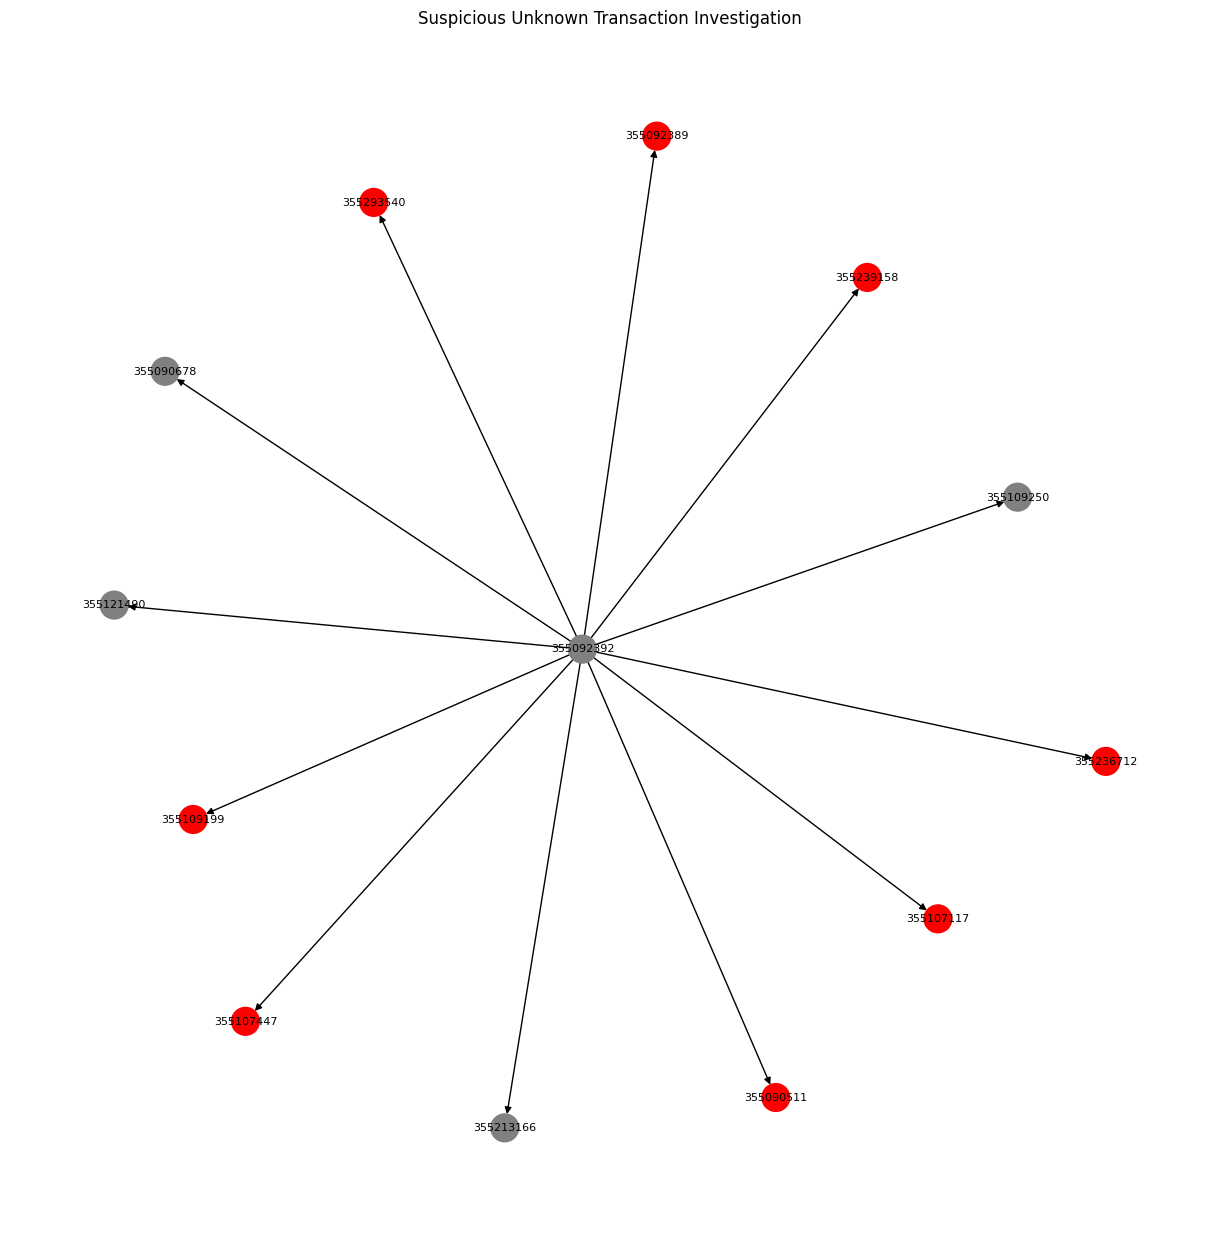

In [ ]:
plt.figure(figsize=(12,12))

nx.draw(
    investigation_graph,
    node_color=investigation_colors,
    with_labels=True,
    node_size=400,
    font_size=8
)

plt.title("Suspicious Unknown Transaction Investigation")

plt.show()

# Executive Summary

This project investigates the use of graph analytics and risk scoring techniques to identify potentially suspicious Bitcoin transactions associated with illicit activity.

Using the Elliptic Bitcoin Dataset, transaction relationships were modeled as a directed network in which transactions interact through flows of cryptocurrency. Exploratory analysis, graph metrics, and rule-based AML scoring techniques were applied to evaluate how proximity to illicit activity and structural importance within the network may increase transaction risk.

The analysis identified several unknown transactions with elevated exposure to illicit nodes, suggesting that graph-based approaches can support AML investigators in prioritizing suspicious activity for further review.

This project demonstrates how network analytics can enhance traditional transaction monitoring by incorporating relationship-based risk signals into AML investigations.

# Business Problem

Financial institutions and cryptocurrency platforms face increasing challenges in identifying transactions potentially associated with money laundering and illicit financial activity.

Traditional AML monitoring systems often focus on isolated transaction behavior, which may fail to detect suspicious relationships hidden within complex transaction networks. In cryptocurrency ecosystems, illicit funds frequently move through multiple intermediary transactions, making detection more difficult through traditional rule-based approaches alone.

This project investigates whether graph-based network analysis can support AML investigations by identifying unknown Bitcoin transactions with elevated exposure to illicit activity.

By combining transaction behavior, network connectivity, and graph centrality metrics, the analysis aims to prioritize suspicious unknown transactions for further investigative review.

# Dataset Description

This project uses the Elliptic Bitcoin Dataset, a publicly available cryptocurrency transaction dataset designed for financial crime and AML research.

The dataset models Bitcoin transactions as a directed graph network, where:

- Nodes represent individual Bitcoin transactions
- Edges represent the flow of Bitcoin between transactions

The dataset contains three primary components:

### Transaction Features
A set of anonymized numerical features describing transaction behavior and structural blockchain characteristics.

### Transaction Classes
Labels identifying transactions as:
- Licit (legitimate activity)
- Illicit (known suspicious or criminal activity)
- Unknown (unlabeled transactions)

### Transaction Edges
Relationships between transactions representing transaction flow connections within the Bitcoin network.

The dataset contains over 200,000 transactions, including a relatively small percentage of illicit activity, reflecting the highly imbalanced nature of real-world AML detection problems.

# Methodology

The analysis was conducted using Python within a Google Colab environment. Data preprocessing, exploratory analysis, graph modeling, and risk scoring techniques were applied throughout the investigation.

The methodology included the following stages:

1. Data loading and preprocessing
   - Merging transaction features, labels, and network relationships
   - Cleaning and standardizing class labels

2. Exploratory Data Analysis (EDA)
   - Evaluating transaction class distribution
   - Comparing behavioral feature distributions between licit and illicit transactions
   - Identifying class imbalance patterns

3. Graph Network Construction
   - Modeling Bitcoin transactions as a directed graph using NetworkX
   - Representing transaction relationships through node-edge structures

4. Network Risk Analysis
   - Measuring illicit transaction proximity
   - Calculating degree and betweenness centrality metrics
   - Evaluating structural influence within the transaction network

5. Rule-Based AML Risk Scoring
   - Combining network exposure and graph metrics into a weighted risk scoring framework
   - Prioritizing unknown transactions with elevated suspicious exposure

# Exploratory Analysis Findings

Initial exploratory analysis revealed a significant class imbalance within the dataset. Illicit transactions represented only a small fraction of the total transaction population, while the majority of transactions remained unlabeled.

This distribution reflects a common challenge in AML investigations, where suspicious activity is rare relative to overall transaction volume.

Comparative analysis between licit and illicit transactions showed differences in several anonymized transaction features, suggesting that certain behavioral characteristics may vary between legitimate and suspicious activity.

However, substantial overlap between classes also demonstrated the limitations of relying solely on isolated transaction behavior for AML detection.

# Graph Analysis Findings

Graph-based analysis revealed that transaction relationships provided additional investigative context beyond isolated transaction features.

By modeling transactions as a directed network, it became possible to evaluate how suspicious exposure may propagate through connected transaction paths.

Several unknown transactions were identified with direct connections to illicit nodes, indicating elevated exposure to suspicious activity despite lacking explicit illicit classification.

Network metrics such as degree and betweenness centrality further highlighted structurally influential transactions that may play intermediary roles within transaction flows.

# Risk Scoring Findings

A rule-based AML risk scoring framework was developed by combining multiple network-based indicators, including:

- proximity to illicit transactions
- transaction connectivity
- graph centrality metrics

Initial scoring approaches generated elevated risk scores for several highly connected licit transactions, demonstrating the importance of model calibration and contextual interpretation within AML systems.

The scoring methodology was subsequently refined to prioritize network influence only when suspicious illicit exposure was also present.

The final framework successfully identified unknown transactions with elevated network-based risk characteristics, supporting the use of graph analytics for AML investigative prioritization.

# Recommendations

The results of this analysis suggest that graph-based transaction monitoring may provide valuable support for AML investigative workflows within cryptocurrency environments.

The following operational recommendations are proposed:

### Enhanced Monitoring of High-Risk Unknown Transactions
Unknown transactions with elevated exposure to illicit activity should be prioritized for additional monitoring and investigative review.

### Integration of Graph Analytics into AML Systems
Traditional transaction monitoring systems may benefit from incorporating relationship-based indicators such as:
- illicit transaction proximity
- network centrality
- transaction connectivity patterns

### Risk-Based Alert Prioritization
Graph-derived risk indicators may help reduce investigative overload by improving alert prioritization and focusing analyst attention on structurally suspicious activity.

### Continuous Model Calibration
AML risk models should be continuously refined to reduce false positives and improve contextual interpretation of highly connected legitimate entities such as exchanges and payment hubs.

# Limitations and Future Improvements

This analysis contains several limitations that should be considered when interpreting the results.

The Elliptic dataset contains anonymized transaction features, limiting direct interpretation of underlying transaction behavior and preventing access to real-world customer or wallet identity information.

Additionally, the risk scoring framework was rule-based and designed primarily for investigative prioritization rather than predictive classification accuracy.

Future improvements could include:
- machine learning-based risk modeling
- community detection and cluster analysis
- temporal transaction pattern analysis
- wallet-level aggregation techniques
- real-time transaction monitoring frameworks

Further research may also explore how graph neural networks and advanced blockchain analytics techniques could improve AML detection capabilities within cryptocurrency ecosystems.

# Final Investigation Summary

The investigation identified several unknown Bitcoin transactions exhibiting elevated exposure to illicit activity through graph-based transaction relationships.

By combining transaction proximity, network connectivity, and structural graph metrics, the analysis demonstrated how suspicious exposure may propagate beyond explicitly labeled illicit transactions.

A focused investigation subgraph revealed unknown transactions directly connected to multiple illicit nodes, suggesting elevated AML risk despite the absence of confirmed illicit classification.

The project highlights the value of graph analytics as a complementary AML investigative tool capable of improving suspicious activity prioritization within cryptocurrency transaction networks.